# Uniswap V3 Trade Cost Analysis

This notebook analyzes trade costs on Uniswap V3 for various trade sizes.
We'll examine how price impact and output amounts change as the input amount increases.

## Setup

In [1]:
import os
import sys
import pandas as pd
from web3 import Web3

# Import from local modules
from tradecost import analyze_trade_costs, get_eth_price_usd
from plots import (
    plot_amount_in_vs_out,
    plot_price_impact,
    plot_cost_of_impact,
    plot_combined_analysis,
    print_summary_stats
)
from config import get_pool_config

In [2]:
# Check for Infura API key
infura_api_key = os.environ.get("INFURA_API_KEY")

# Set up Web3
rpc_url = f"https://mainnet.infura.io/v3/{infura_api_key}"
w3 = Web3(Web3.HTTPProvider(rpc_url))

if not w3.is_connected():
    raise ConnectionError("Failed to connect to Ethereum node")

print(f"Connected to Ethereum mainnet via Infura")
print(f"Latest block: {w3.eth.block_number}")

Connected to Ethereum mainnet via Infura
Latest block: 23778885


## Configure Trade Parameters

In [3]:
# Trade parameters
token_in_symbol = "USDC"
token_out_symbol = "WBTC"

# token_in_symbol = "USDC"
# token_out_symbol = "USDT"

# token_in_symbol = "RPL"
# token_out_symbol = "WETH"

token_in_symbol = "DAI"
token_out_symbol = "USDC"

token_in_symbol = "WETH"
token_out_symbol = "WBTC"

# Amount range (in human-readable units)
amounts_in = [1, 10, 100, 1000, 10000, 100000, 1000000]
# amounts_in = [.01]

# Optional: specify fee tier (100, 500, 3000, 10000) or None for default
fee = None

## Analyze Trade Costs

In [4]:
# Run analysis - this produces the complete dataframe
df = analyze_trade_costs(
    w3=w3,
    token_in_symbol=token_in_symbol,
    token_out_symbol=token_out_symbol,
    amounts_in=amounts_in,
    fee=fee,
    verbose=True
)

output_file = f"../data/uniswap_trade_costs_{token_in_symbol}_{token_out_symbol}.csv"
# df = pd.read_csv(output_file) # optionally load pre-computed results

Analyzing trade costs for WETH → WBTC
Pool: 0xCBCdF9626bC03E24f779434178A73a0B4bad62eD
Fee tier: 0.3%
ETH Price: $3,412.02

Querying 7 different trade sizes...
Note: Low-liquidity pools may fail for larger trade sizes due to high price impact
✓ $1 WETH → 0.03325456 WBTC (Impact: 30.48 bps)
✓ $10 WETH → 0.33240279 WBTC (Impact: 34.76 bps)
✓ $100 WETH → 3.30916457 WBTC (Impact: 79.32 bps)
✓ $1,000 WETH → 32.14771687 WBTC (Impact: 362.30 bps)
✓ $10,000 WETH → 75.36380033 WBTC (Impact: 7740.64 bps)
✓ $100,000 WETH → 75.69982285 WBTC (Impact: 9773.06 bps)
✓ $1,000,000 WETH → 75.72654705 WBTC (Impact: 9977.30 bps)

Successfully collected 7/7 quotes


In [5]:
# Display the dataframe
df

,amount_in,amount_out,ideal_amount_out,cost_of_impact,cost_of_impact_usd,exec_price,exec_price_inv,mid_price,mid_price_inv,price_after,price_after_inv,price_impact_bps,price_impact_pct,ticks_crossed,gas_estimate,eth_price_usd,gas_cost_usd
0,1,0.033255,0.033356,0.000102,0.003048,0.033255,30.071064,0.033356,29.979415,3.335304e-02,2.998228e+01,30.477421,0.304774,1,85587,3412.023941,5.840498
1,10,0.332403,0.333562,0.001159,0.034759,0.033240,30.083983,0.033356,29.979415,3.332439e-02,3.000805e+01,34.758782,0.347588,1,85591,3412.023941,5.840771
2,100,3.309165,3.335622,0.026458,0.793182,0.033092,30.219108,0.033356,29.979415,3.302235e-02,3.028252e+01,79.318176,0.793182,3,138836,3412.023941,9.474235
3,1000,32.147717,33.356221,1.208504,36.230252,0.032148,31.106408,0.033356,29.979415,3.151575e-02,3.173017e+01,362.302518,3.623025,11,331642,3412.023941,22.631409
4,10000,75.363800,333.562212,258.198411,7740.637347,0.007536,132.689699,0.033356,29.979415,4.609211e-05,2.169569e+04,7740.637347,77.406373,132,4570525,3412.023941,311.894814
5,100000,75.699823,3335.622116,3259.922293,97730.563589,0.000757,1321.007054,0.033356,29.979415,3.037655e-07,3.292013e+06,9773.056359,97.730564,135,4768109,3412.023941,325.378041
6,1000000,75.726547,33356.221161,33280.494614,997729.762413,0.000076,13205.408657,0.033356,29.979415,2.918080e-09,3.426911e+08,9977.297624,99.772976,137,4907328,3412.023941,334.878412


## Visualizations

### Amount In vs Amount Out

In [6]:
fig1 = plot_amount_in_vs_out(df, token_in_symbol, token_out_symbol)
fig1.show()

### Price Impact Analysis

In [7]:
fig2 = plot_price_impact(df, token_in_symbol, token_out_symbol)
fig2.show()

### Cost of Price Impact

In [8]:
fig3 = plot_cost_of_impact(df, token_in_symbol, token_out_symbol)
fig3.show()

### Combined Analysis

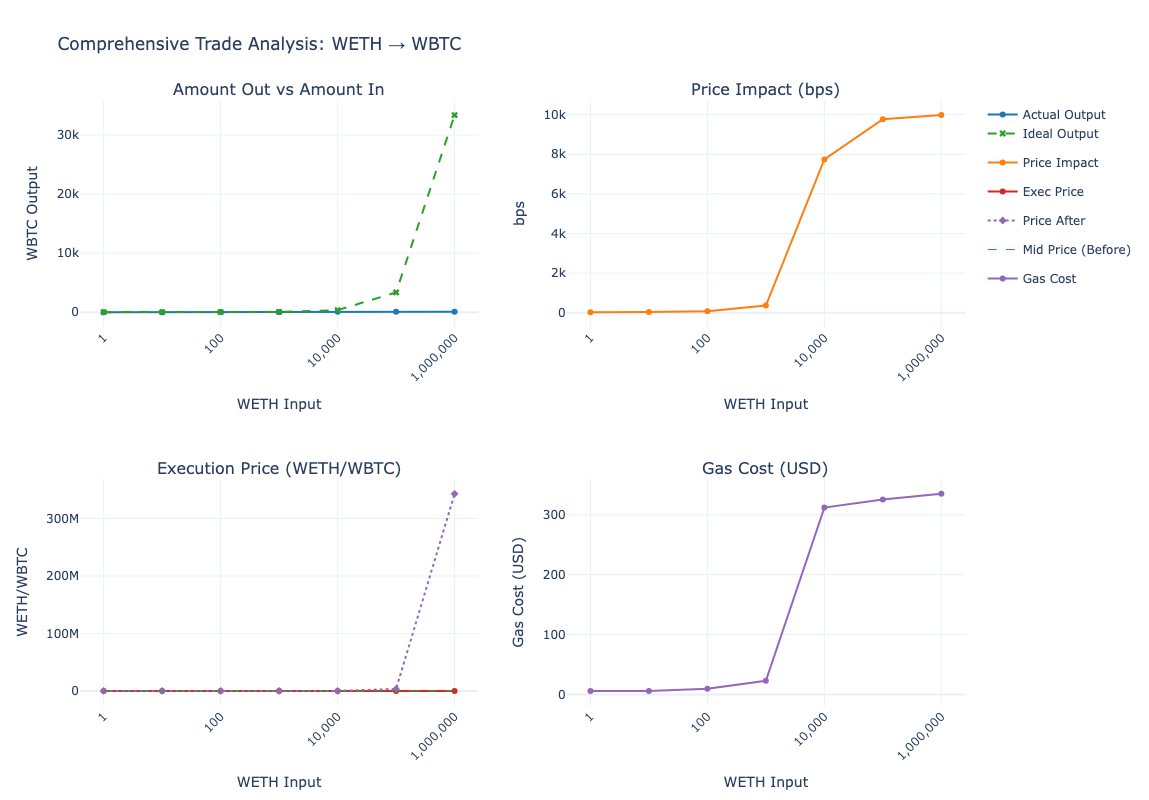

In [12]:
fig4 = plot_combined_analysis(df, token_in_symbol, token_out_symbol)
fig4.show()

## Summary Statistics

In [10]:
# Get pool config for summary (with auto-discovery enabled)
pool_config = get_pool_config(token_in_symbol, token_out_symbol, fee, w3=w3)

# Print summary statistics
print_summary_stats(
    df=df,
    token_in_symbol=token_in_symbol,
    token_out_symbol=token_out_symbol,
    pool_address=pool_config['address'],
    fee=pool_config['fee']
)

Trade Cost Analysis Summary: WETH → WBTC

Pool: 0xCBCdF9626bC03E24f779434178A73a0B4bad62eD
Fee Tier: 0.3%
ETH Price: $3,412.02

Trade Size Range: $1 - $1,000,000

Price Impact:
  Min: 30.48 bps (0.30%)
  Max: 9977.30 bps (99.77%)
  Mean: 3999.69 bps (40.00%)

Execution Price:
  Min: 0.0000757265 WBTC/WETH
  Max: 0.0332545600 WBTC/WETH
  Mid Price: 0.0333562212 WBTC/WETH
  (Inverted) Min: 30.07 WETH/WBTC
  (Inverted) Max: 13205.41 WETH/WBTC
  (Inverted) Mid Price: 29.98 WETH/WBTC

Cost of Impact:
  Total tokens lost: 36799.85154099 WBTC
  Total USD lost: $1,103,238.02
  Average cost per trade: $157,605.43

Gas Costs:
  Min: 85,587 gas ($5.84)
  Max: 4,907,328 gas ($334.88)
  Mean: 2,126,803 gas ($145.13)
  Total gas cost: $1015.94


## Export Results

In [11]:
# Export to CSV
os.makedirs(os.path.dirname(output_file), exist_ok=True)
df.to_csv(output_file, index=False)
print(f"Results exported to: {output_file}")

Results exported to: ../data/uniswap_trade_costs_WETH_WBTC.csv


## Analyze Different Token Pairs

To analyze different token pairs, simply change the parameters and re-run:

In [ ]:
# Example: Analyze USDC -> WETH
# df_weth = analyze_trade_costs(
#     w3=w3,
#     token_in_symbol="USDC",
#     token_out_symbol="WETH",
#     amounts_in=[1, 10, 100, 1000, 10000, 100000],
#     verbose=True
# )
# fig = plot_combined_analysis(df_weth, "USDC", "WETH")
# fig.show()